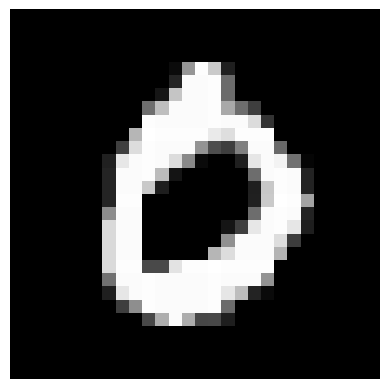

0


In [24]:
from keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = mnist.load_data()

def show(img):
  plt.imshow(img, cmap="gray")
  plt.axis("off")
  plt.show()

n = 3

show(X_test[n])
print(y_test[n])

In [4]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

In [12]:
# Um percéptron com 2 camadas ocultas
# Baseado no código do artigo https://abtinmy.github.io/CS-SBU-NeuralNetwork/lectures/introduction/MLP-Scratch-Iris
class MLP:
  def __init__(self, input_size, hidden1_size, hidden2_size, output_size, learning_rate=0.01):
    self.input_size = input_size
    self.hidden1_size = hidden1_size
    self.hidden2_size = hidden2_size
    self.output_size = output_size
    self.learning_rate = learning_rate

    self.weights1 = np.random.randn(input_size, hidden1_size) * np.sqrt(2 / input_size)
    self.weights2 = np.random.randn(hidden1_size, hidden2_size) * np.sqrt(2 / hidden1_size)
    self.weights3 = np.random.randn(hidden2_size, output_size) * np.sqrt(2 / hidden2_size)

    self.bias1 = np.zeros((1, self.hidden1_size))
    self.bias2 = np.zeros((1, self.hidden2_size))
    self.bias3 = np.zeros((1, self.output_size))

  def forward(self, X):
    z1 = X @ self.weights1 + self.bias1
    a1 = relu(z1)
    z2 = a1 @ self.weights2 + self.bias2
    a2 = relu(z2)
    z3 = a2 @ self.weights3 + self.bias3
    a3 = softmax(z3)
    return z1, a1, z2, a2, z3, a3

  def compute_loss(self, y, y_pred):
    return -np.mean(np.sum(y * np.log(y_pred + 1e-8), axis=1))

  def fit(self, X, y, epochs=1000, batch_size=64, epochs_per_loss=100):
    n = X.shape[0]
    for epoch in range(epochs):

      # Embaralha os dados em ordem aleatória
      idx = np.random.permutation(n)
      X, y = X[idx], y[idx]

      # Treinamos o modelo em batches para evitar sobrecarregar a máquina
      total_loss = 0 # Aqui guardaremos a soma de toda a perda de cada um dos batches.

      for i in range(0, n, batch_size):
        X_batch = X[i:i+batch_size]
        y_batch = y[i:i+batch_size]
        m = X_batch.shape[0]
      
        # Forward
        z1, a1, z2, a2, z3, y_pred = self.forward(X_batch)

        loss = self.compute_loss(y_batch, y_pred)
        total_loss += loss * m

        # Backpropagation
        delta3 = (y_pred - y_batch) / m
        d_weights3 = a2.T @ delta3
        d_bias3 = np.sum(delta3, axis=0, keepdims=True)

        delta2 = (delta3 @ self.weights3.T) * relu_derivative(z2)
        d_weights2 = a1.T @ delta2
        d_bias2 = np.sum(delta2, axis=0, keepdims=True)

        delta1 = (delta2 @ self.weights2.T) * relu_derivative(z1)
        d_weights1 = X_batch.T @ delta1
        d_bias1 = np.sum(delta1, axis=0, keepdims=True)

        # Atualiza pesos e vieses
        self.weights1 -= self.learning_rate * d_weights1
        self.weights2 -= self.learning_rate * d_weights2
        self.weights3 -= self.learning_rate * d_weights3
        self.bias1 -= self.learning_rate * d_bias1
        self.bias2 -= self.learning_rate * d_bias2
        self.bias3 -= self.learning_rate * d_bias3

      # Imprime perda na época
      print(f"Epoch {epoch+1}, Loss: {total_loss / n:.4f}")

  def predict(self, X):
    _, _, _, _, _, y_pred = self.forward(X)
    return np.argmax(y_pred, axis=1)


In [13]:
def fit_one_hot(y):
    classes = np.unique(y)
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

    encoded = np.zeros((len(y), len(classes)))
    for i, label in enumerate(y):
        encoded[i, class_to_idx[label]] = 1

    return encoded, classes

def transform_one_hot(y, classes):
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

    encoded = np.zeros((len(y), len(classes)))
    for i, label in enumerate(y):
        encoded[i, class_to_idx[label]] = 1

    return encoded

In [25]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

classes = np.unique(y_train)

y_train = np.eye(len(classes))[np.searchsorted(classes, y_train)]
y_test = np.eye(len(classes))[np.searchsorted(classes, y_test)]

print(X_train.shape)  # (60000, 784)
print(y_train.shape)  # (60000, 10)

(60000, 784)
(60000, 10)


In [15]:
mlp = MLP(
    input_size=784,
    hidden1_size=128,
    hidden2_size=64,
    output_size=10,
    learning_rate=0.01
)

mlp.fit(X_train, y_train, epochs=100)

Epoch 1, Loss: 0.7543
Epoch 2, Loss: 0.3413
Epoch 3, Loss: 0.2841
Epoch 4, Loss: 0.2507
Epoch 5, Loss: 0.2261
Epoch 6, Loss: 0.2066
Epoch 7, Loss: 0.1912
Epoch 8, Loss: 0.1777
Epoch 9, Loss: 0.1660
Epoch 10, Loss: 0.1563
Epoch 11, Loss: 0.1470
Epoch 12, Loss: 0.1393
Epoch 13, Loss: 0.1322
Epoch 14, Loss: 0.1261
Epoch 15, Loss: 0.1202
Epoch 16, Loss: 0.1150
Epoch 17, Loss: 0.1099
Epoch 18, Loss: 0.1054
Epoch 19, Loss: 0.1014
Epoch 20, Loss: 0.0975
Epoch 21, Loss: 0.0937
Epoch 22, Loss: 0.0903
Epoch 23, Loss: 0.0872
Epoch 24, Loss: 0.0843
Epoch 25, Loss: 0.0815
Epoch 26, Loss: 0.0786
Epoch 27, Loss: 0.0763
Epoch 28, Loss: 0.0740
Epoch 29, Loss: 0.0716
Epoch 30, Loss: 0.0696
Epoch 31, Loss: 0.0674
Epoch 32, Loss: 0.0654
Epoch 33, Loss: 0.0636
Epoch 34, Loss: 0.0618
Epoch 35, Loss: 0.0600
Epoch 36, Loss: 0.0584
Epoch 37, Loss: 0.0569
Epoch 38, Loss: 0.0552
Epoch 39, Loss: 0.0540
Epoch 40, Loss: 0.0523
Epoch 41, Loss: 0.0509
Epoch 42, Loss: 0.0496
Epoch 43, Loss: 0.0482
Epoch 44, Loss: 0.04

In [26]:
mlp.predict(X_test[3])

array([0])

TypeError: Invalid shape (784,) for image data

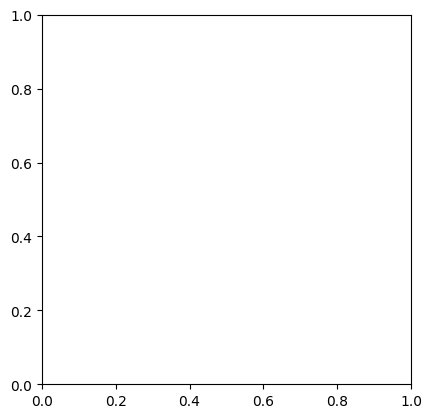